##### Build a simple workflow or graph using langgraph
- State Schema: serves a input schema for all nodes.

In [9]:
from typing_extensions import TypedDict

class State(TypedDict):       # provides type hints for key-value pairs in the dictionary
    graph_info: str


# Flow the input to the entire workflow!

In [10]:
def play(state:State):
    print("Start Play node has been called")
    return {"graph_info":state["graph_info"] + "I am planning to play"}

def cricket(state:State):
    print("Cricket node has been called")
    return {"graph_info":state["graph_info"] + " Cricket"}

def badminton(state:State):
    print("My badminton node has been called")
    return {"graph_info":state['graph_info'] + " Badminton"}

In [ ]:
import random
from typing import Literal                           ## literal = constant

def random_play(state:State)-> Literal['cricket','badminton']:
    if random.random()>0.5:
        return "cricket"
    else:
        return "badminton"

##### Design the entire graph or workflow

In [14]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)
workflow.add_node("play", play)
workflow.add_node("cricket", cricket)
workflow.add_node("badminton", badminton)

# Schedule the flow of the graph
workflow.add_edge(START, "play")
workflow.add_conditional_edges("play", random_play)
workflow.add_edge("cricket", END)
workflow.add_edge("badminton", END)

In [15]:
app = workflow.compile()    ## compile the graph

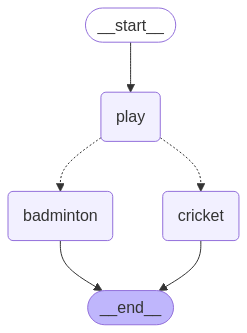

In [16]:
from IPython.display import Image, display

# visualize the graph

display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
app.invoke({"graph_info": "Hi, Brigu here! "})

Start Play node has been called
Cricket node has been called


{'graph_info': 'Hi, Brigu here! I am planning to play Cricket'}

In [20]:
app.invoke({"graph_info": "Hi, sharma here! "})

Start Play node has been called
My badminton node has been called


{'graph_info': 'Hi, sharma here! I am planning to play Badminton'}